# PEG PNIPAM: Crystallization

### Set up()

In [118]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
import scipy
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter
import ipywidgets as widgets
from ipywidgets import interact, IntSlider

✗ Error: unmatched ')' (experiment_catalog.py, line 104)


### Functions

In [3]:
def Avrami(x, A, k, n):
    return A * (1 - np.exp(-k * x ** n))

def Avrami_shifted(x, A, k, n, x0):
    res = Avrami(abs(x-x0), A, k, n)
    res[x < x0] *= 0
   
    return res
   
def Avraami_2(t, A, K1, n1, K2, n2):
    N = 300
    theta_arr = np.linspace(0, t, N)
 
    res = 0
 
    for theta in theta_arr:
        res += (1 - np.exp(-K2 * (t - theta) ** n2)) * theta ** (n1 - 1) * np.exp(-K1 * (theta ** n1)) * t / N
    return A * K1 * n1 * res
    
def Avraami_2_linspace(t,A, K1, n1, K2, n2):
    res = np.zeros(len(t))
 
    for i in range(len(t)):
        res[i] = Avraami_2(t[i],A, K1, n1, K2, n2)
    return res

def Model(t, A1, K1, n1, A2,  K2, n2):
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

def Model(t, A, r, K1, n1, K2, n2):
    return A * (r * Avrami(t, 1, K1, n1) + (1 - r) * Avraami_2_linspace(t, 1, K1, n1, K2, n2))

def read_data(path):
    return pd.read_csv(path, sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

In [115]:
def Fit(time, BB, cr, point1=15, point2=25, point3=20, bound1=0.):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
    ax1.set_xlabel('time / s')
    ax1.set_ylabel('BB peak')
    ax2.set_xlabel('time / s')
    ax2.set_ylabel('Crystallinity')
    x = np.linspace(min(time), max(time), 1000)
    ax1.set_title('BB Ampl fit')
    ax2.set_title('Crystallinity Ampl fit')
    # ax3.set_title('Crystallinity fit')
    
    # FIRST STEP
    ax1.scatter(time[point1], 1-BB[point1], color='r', marker='*', zorder=10)
    ax2.scatter(time[point2], cr[point2], color='r', marker='*', zorder=10)
    # ax3.scatter(time[point3], cr[point3], color='r', marker='*', zorder=10)
    ax1.scatter(time, 1 - BB, color='black')
    ax1.set_xlim(-100, max(time) + 100)
    ax1.set_ylim(-0.05, 1.05)
    ax2.set_xlim(-100, max(time) + 100)
    ax2.set_ylim(-0.05, 1.05)
    # ax3.set_xlim(-100, max(time) + 100)
    # ax3.set_ylim(-0.05, 1.05)


    
    bounds = ([0, 0, 2.5], 
              [1, np.inf, 3.1])
    
    p, cov = curve_fit(Avrami, time[:point1], 1-BB[:point1], p0=[1,  6.8594e-08, 3.06619], bounds=bounds)
    ax1.plot(x, Avrami(x, *p), color='r', linestyle='--')
    
    K1 = p[1]
    n1 = p[2]
    
    # SECOND STEP
    ax2.scatter(time, cr, color='black')
    
    epsilon = 1e-10
    
    bounds = ([0, bound1, K1 - epsilon, n1 - epsilon, 0, 0.], 
              [1, 1, K1 + epsilon, n1 + epsilon, np.inf, 2])
    p0 = [0.7, 0.4, K1, n1, 0.00215978, 1.5]

    sigma_part1 = 0.01 * np.ones(10) + epsilon
    sigma_part2 = 0.05 * np.ones(point2 - 12) + epsilon
    sigma_array = np.concatenate((sigma_part1, sigma_part2)) 
    
    p, cov = curve_fit(Model, time[2:point2], cr[2:point2], bounds=bounds, p0=p0, sigma=sigma_array)
    A, r, K2, n2 = p[0], p[1], p[4], p[5]
    
    
    ax2.plot(x, A * r * Avrami(x, 1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
    ax2.plot(x, A * (1 - r) * Avraami_2_linspace(x, 1, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
    ax2.plot(x, Model(x, *p), color='r', linestyle='--')
    
    ax2.legend(fontsize=10, loc=4)

    # THIRD STEP
    # ax3.scatter(time, cr, color='black')
    
    # epsilon = 1e-10
    
    # bounds = ([A - epsilon, 0.0, K1 - epsilon, n1 - epsilon, 0, 0], 
    #           [A + epsilon, 1, K1 + epsilon, n1 + epsilon, np.inf, 1.8])
    # p0 = [A, 0.5, K1, n1, 0.00215978, 1.28298]
    
    # p, cov = curve_fit(Model, time[:point3], cr[:point3], bounds=bounds, p0=p0)
    # A, r, K2, n2 = p[0], p[1], p[4], p[5]
    
    
    # ax3.plot(x, A * r * Avrami(x, 1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
    # ax3.plot(x, A * (1 - r) * Avraami_2_linspace(x, 1, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
    # ax3.plot(x, Model(x, *p), color='r', linestyle='--')
    
    # ax3.legend(fontsize=10, loc=4)

    # plt.show()
    print(*cov[0])
    print(*cov[1])
    print(*cov[2])
    print(*cov[3])
    print(*cov[4])
    print(*cov[5])
    return p, 

In [58]:
def Model(t, A, r, K1, n1, K2, n2):
    return A * (r * Avrami(t, 1, K1, n1) + (1 - r) * Avraami_2_linspace(t, 1, K1, n1, K2, n2))

In [19]:
def three_step_fit(time, BB, cr):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))
    ax1.set_xlabel('time / s')
    ax1.set_ylabel('BB peak')
    ax2.set_xlabel('time / s')
    ax2.set_ylabel('Crystallinity')
    x = np.linspace(min(time), max(time), 1000)
    ax1.set_title('BB Ampl fit')
    ax2.set_title('Crystallinity Ampl fit')
    ax3.set_title('Crystallinity fit')
    
    # FIRST STEP
    ax1.scatter(time[point1], 1-BB[point1], color='r', marker='*', zorder=10)
    ax2.scatter(time[point2], cr[point2], color='r', marker='*', zorder=10)
    ax3.scatter(time[point3], cr[point3], color='r', marker='*', zorder=10)
    ax1.scatter(time, 1 - BB, color='black')
    ax1.set_xlim(-100, max(time) + 100)
    ax1.set_ylim(-0.05, 1.05)
    ax2.set_xlim(-100, max(time) + 100)
    ax2.set_ylim(-0.05, 1.05)
    ax3.set_xlim(-100, max(time) + 100)
    ax3.set_ylim(-0.05, 1.05)

    

In [97]:

def Avraami_2_linspace(t, A, K1, n1, K2, n2):
    # Vectorize the Avraami_2 function
    vfunc = np.vectorize(Avraami_2)
    return vfunc(t, A, K1, n1, K2, n2)

# Analysis

### T$_{cr}$ effect

In [71]:
Model

<function __main__.Model(t, A, r, K1, n1, K2, n2)>

In [2]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\576_12_Cryst_at_15C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 17, 30, 8, bound1=0.)


NameError: name 'read_data' is not defined

array([6.91603556e-01, 2.08573832e-01, 6.68101361e-08, 3.06618999e+00,
       6.49426738e-02, 6.32905023e-01])

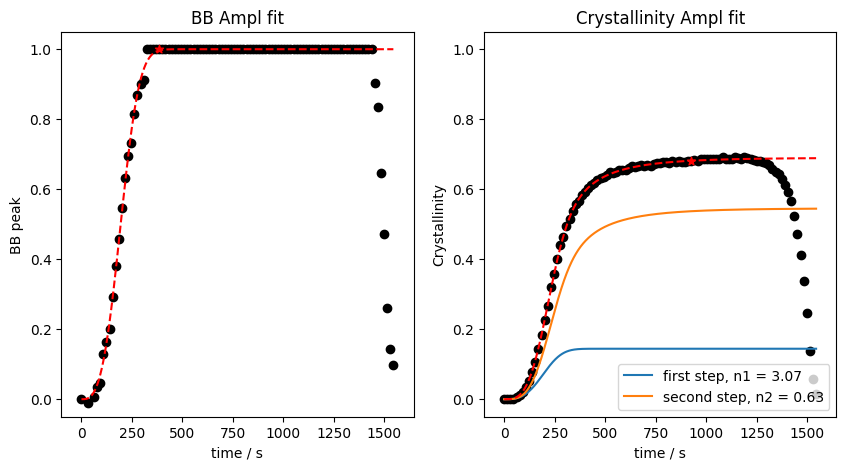

In [50]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\576_12_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 25, 60, 8)


array([6.87876068e-01, 1.25958623e-14, 3.89449499e-08, 2.97829492e+00,
       3.61694912e-02, 7.80291465e-01])

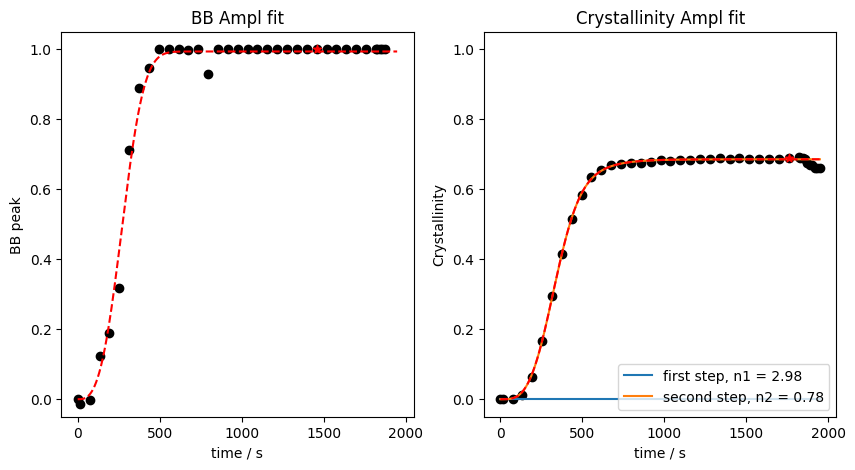

In [51]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\576_12_Cryst_at_15C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 25, 30, 8)


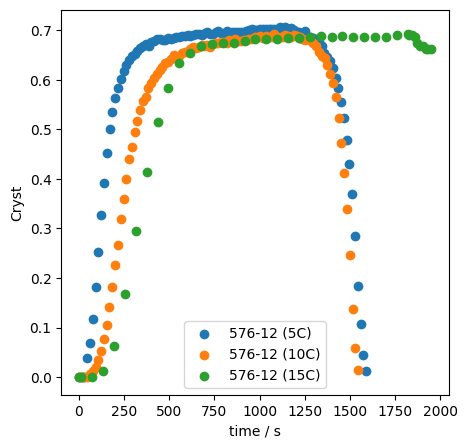

In [22]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\576_12_Cryst_at_5C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))
plt.xlabel('time / s')
plt.ylabel('Cryst')
plt.scatter(time, cr, label='576-12 (5C)')

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\576_12_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr, label='576-12 (10C)')

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\576_12_Cryst_at_15C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr, label='576-12 (15C)')
plt.legend()

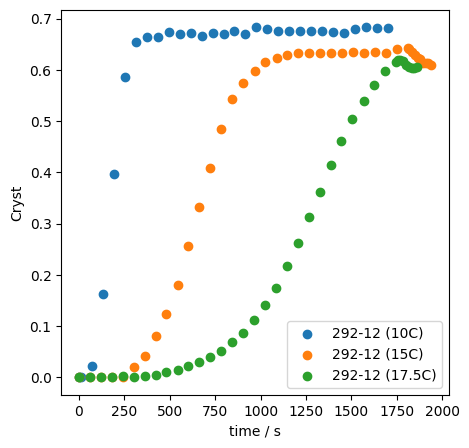

In [23]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))
plt.xlabel('time / s')
plt.ylabel('Cryst')
plt.scatter(time, cr, label='292-12 (10C)')

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_15C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr, label='292-12 (15C)')

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_17_5C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr, label='292-12 (17.5C)')
plt.legend()

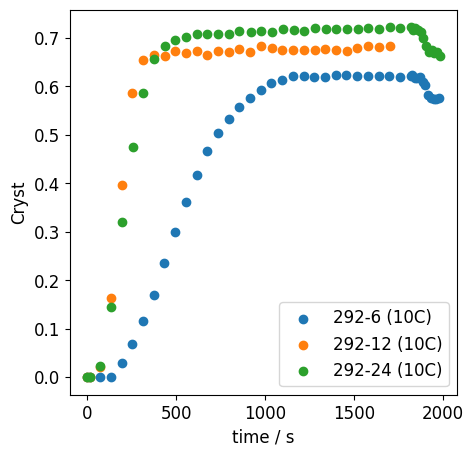

In [203]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_6_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))
plt.xlabel('time / s')
plt.ylabel('Cryst')
plt.scatter(time, cr, label='292-6 (10C)')

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr, label='292-12 (10C)')

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_24_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr, label='292-24 (10C)')
plt.legend()

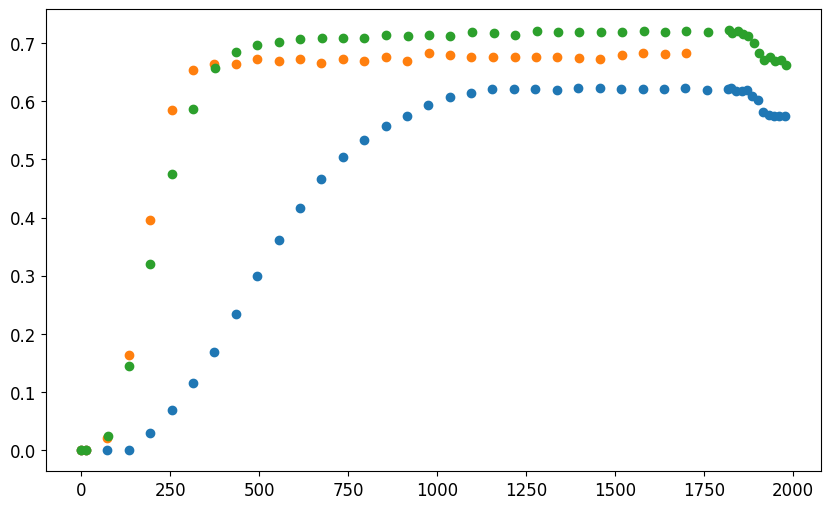

In [164]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_6_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr)

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr)

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_24_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr)

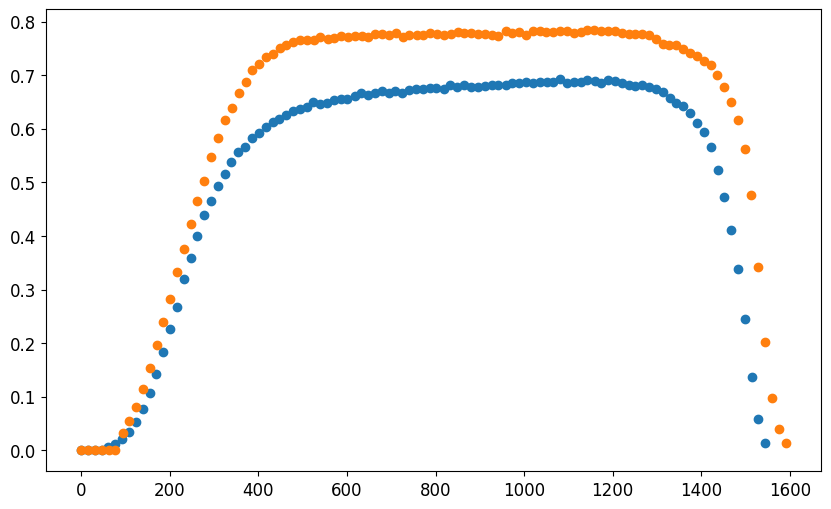

In [165]:

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\576_12_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr)

df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\576_24_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

plt.scatter(time, cr)

#### n_L effect

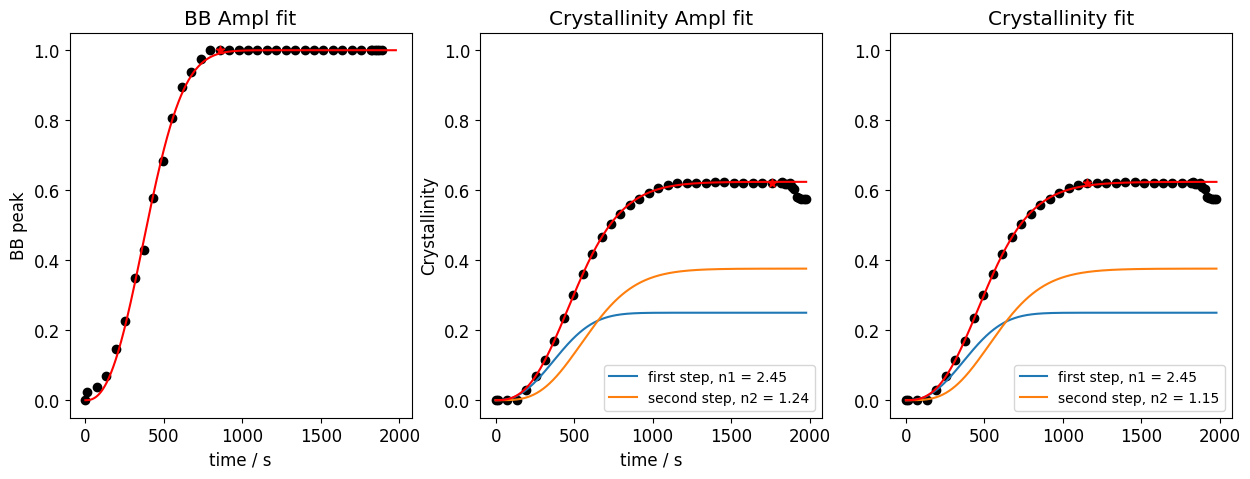

array([6.25270177e-01, 3.38040263e-01, 3.13454456e-07, 2.44678829e+00,
       2.12553846e-03, 1.15148433e+00])

In [153]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_6_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 15, 30, 20)

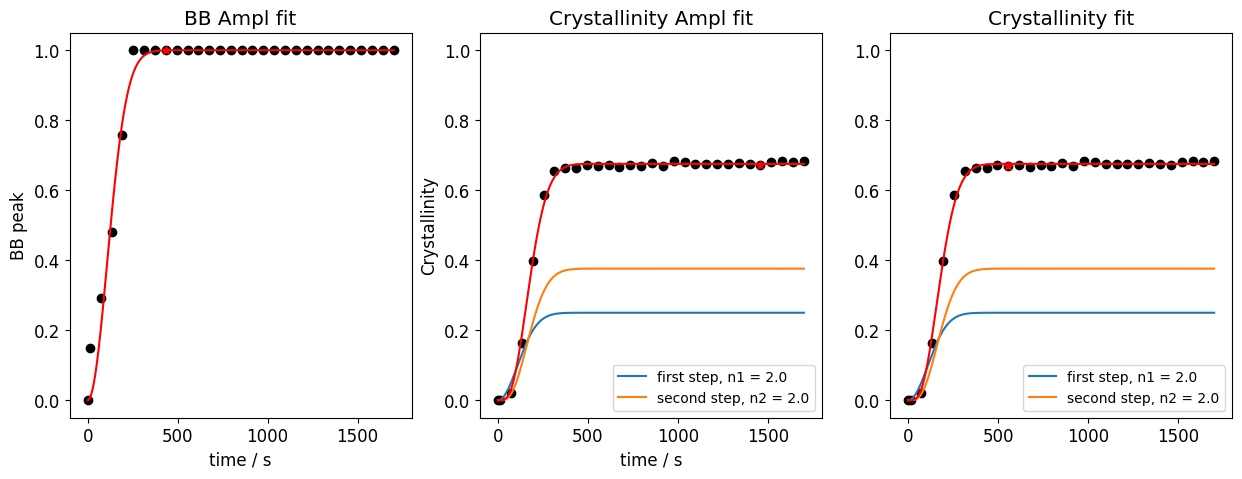

array([6.77580704e-01, 1.90191279e-26, 4.25147191e-05, 2.00000000e+00,
       3.46274444e-04, 2.00000000e+00])

In [157]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 8, 25, 10)

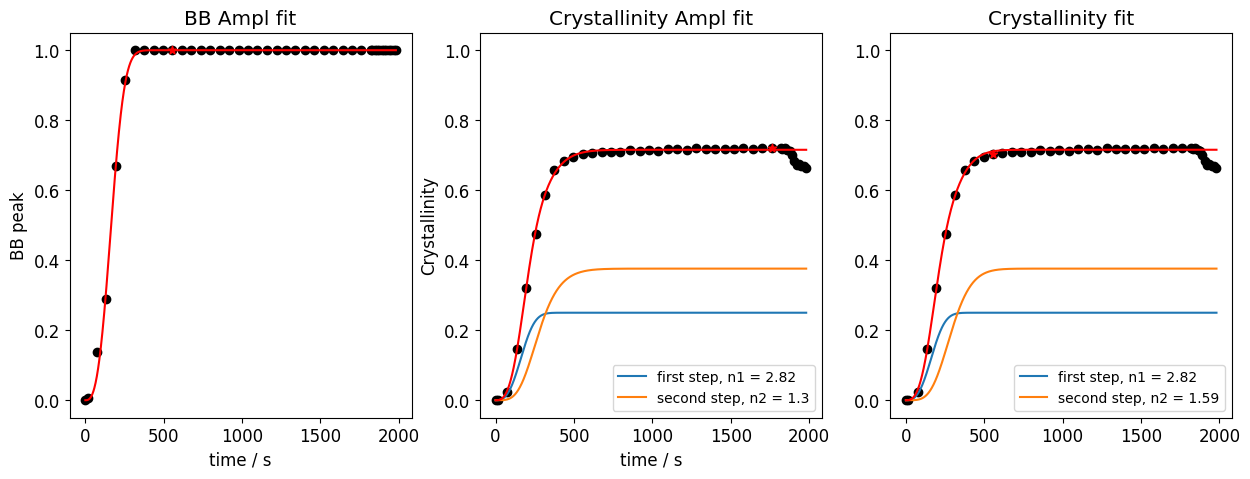

array([7.16712455e-01, 5.51854456e-01, 3.80840024e-07, 2.82412722e+00,
       3.80152411e-04, 1.58980997e+00])

In [155]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_24_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 10, 30, 10)

##### 292-6

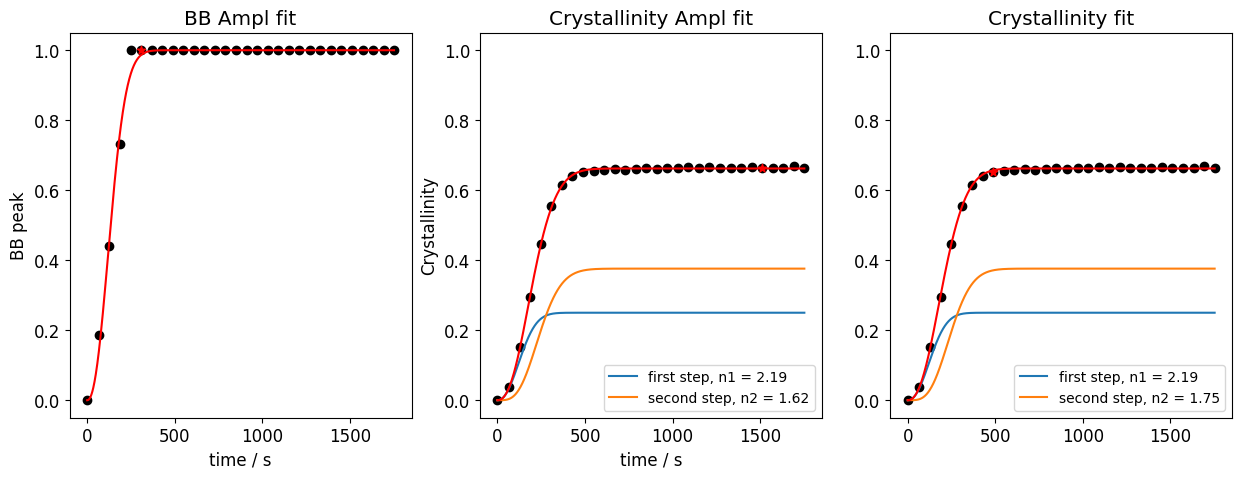

array([6.63578437e-01, 3.71789873e-01, 1.49890503e-05, 2.19323936e+00,
       2.17221036e-04, 1.74763506e+00])

In [124]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_6_Cryst_at_5C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 5, 25, 8)

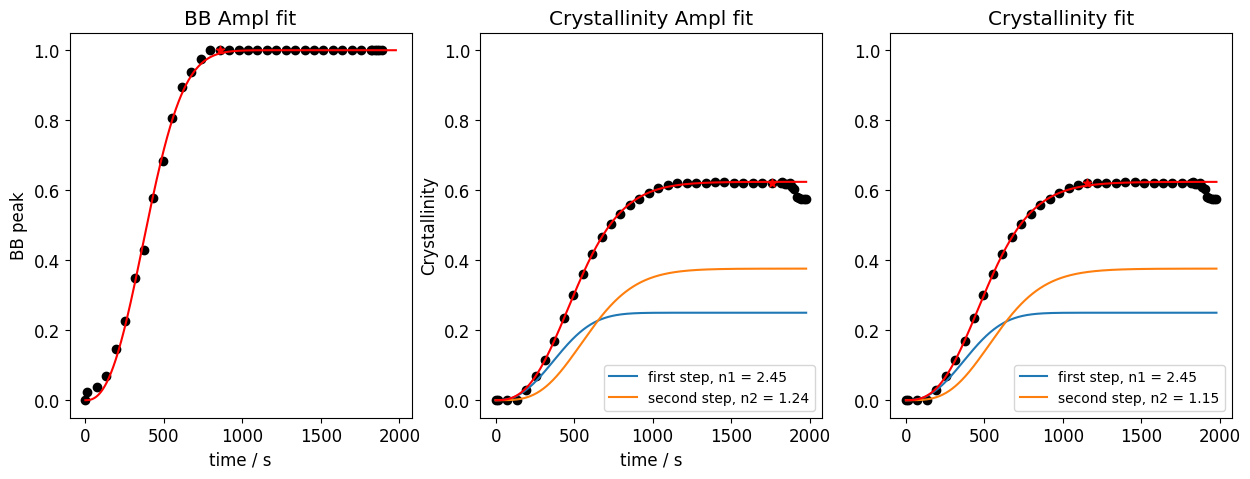

array([6.25270206e-01, 3.38039988e-01, 3.13454456e-07, 2.44678829e+00,
       2.12554963e-03, 1.15148343e+00])

In [125]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_6_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 15, 30, 20)

##### 292-12

C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\trf.py:234: RuntimeWarning: divide by zero encountered in divide
  Delta = norm(x0 * scale_inv / v**0.5)
C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\trf.py:363: RuntimeWarning: invalid value encountered in scalar divide
  alpha *= Delta / Delta_new
C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\common.py:49: RuntimeWarning: invalid value encountered in scalar divide
  t2 = c / q
C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\trf.py:363: RuntimeWarning: invalid value encountered in scalar multiply
  alpha *= Delta / Delta_new
C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\common.py:398: RuntimeWarning: invalid value encountered in cast
  return min_step, np.equal(steps, min_step) * np.sign(s).astype(int)


RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

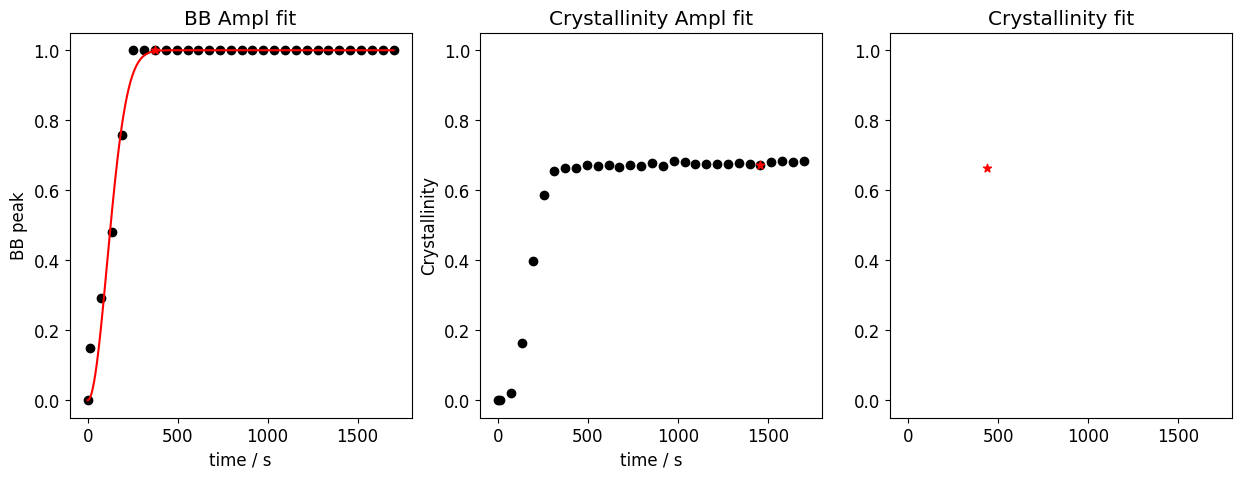

In [126]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 7, 25, 20)

In [ ]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_15C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 20, 25, 20)

C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\trf.py:234: RuntimeWarning: divide by zero encountered in divide
  Delta = norm(x0 * scale_inv / v**0.5)
C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\trf.py:363: RuntimeWarning: invalid value encountered in scalar divide
  alpha *= Delta / Delta_new
C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\trf.py:363: RuntimeWarning: invalid value encountered in scalar multiply
  alpha *= Delta / Delta_new
C:\Users\LabPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_lsq\common.py:398: RuntimeWarning: invalid value encountered in cast
  return min_step, np.equal(steps, min_step) * np.sign(s).astype(int)


RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

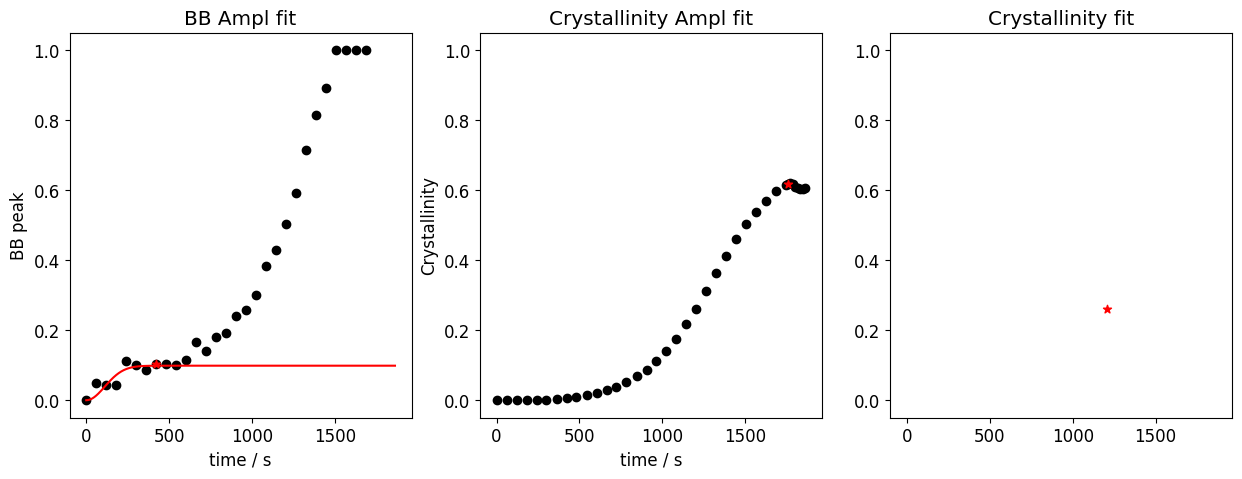

In [128]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_12_Cryst_at_17_5C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 7, 30, 20)

##### 292-24

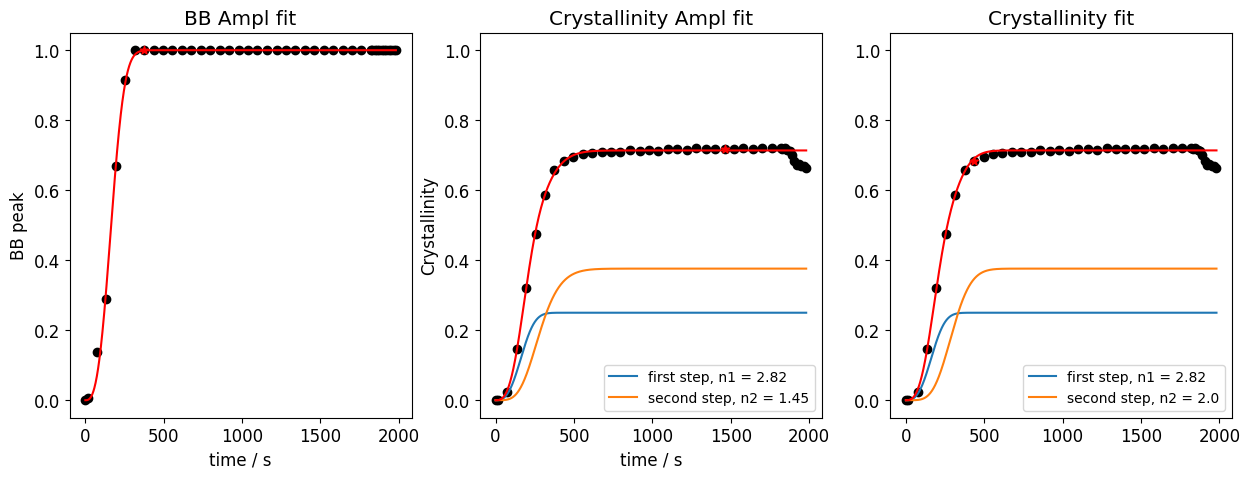

array([7.14766068e-01, 5.80422152e-01, 3.81589835e-07, 2.82374749e+00,
       4.63463193e-05, 2.00000000e+00])

In [129]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_24_Cryst_at_10C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 7, 25, 8)

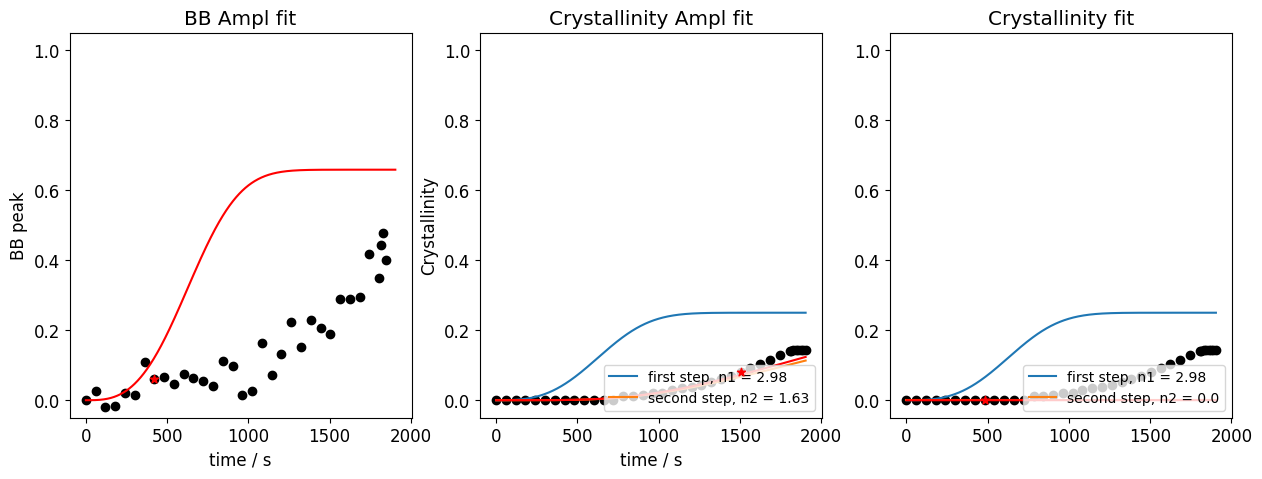

array([4.14968358e-01, 6.91387767e-04, 2.91792019e-09, 2.98290866e+00,
       2.98746636e-06, 1.77523936e-03])

In [130]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_24_Cryst_at_20C.txt")

time = df['time']
BB = df['BB']
cr = df['cr']

Fit(time, BB, cr, 7, 25, 8)

##### 888-24 

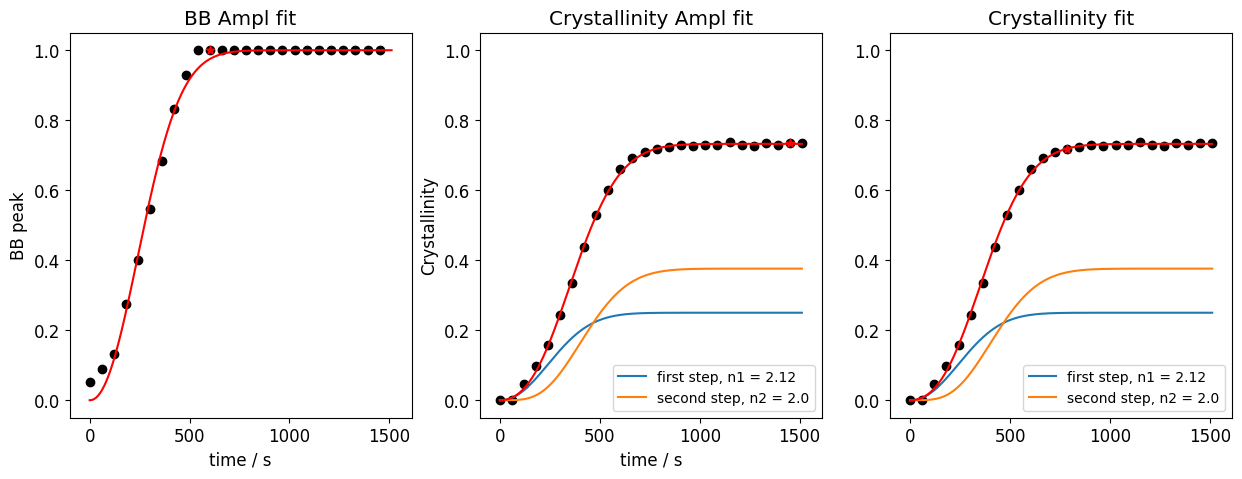

array([7.34092982e-01, 3.55481097e-01, 4.68886225e-06, 2.12125570e+00,
       3.32661569e-05, 2.00000000e+00])

In [144]:
df = read_data(r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\888_24_Cryst_at_15C.txt")

time = np.array(df['time'])[6:] - np.array(df['time'][6])
BB = np.array(df['BB'])[6:]
cr = np.array(df['cr'])[6:]

Fit(time, BB, cr, 10, 24, 13)